# Edge-weighted Graph Decomposition


In [1]:
import os
from pathlib import Path

_cwd = Path.cwd().resolve()
_NOTEBOOK_DIR = _cwd if _cwd.name == "notebook" else _cwd / "notebook"
OUTPUT_DIR = _NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import networkx as nx
import torch
from scipy import sparse
from itertools import combinations
from typing import Dict, List, Optional, Tuple

from TopNMF import (
    TopologicalNMF,
    GraphFiltrationPH,
    clique_deviation_loss,
    generate_edge_weighted_graph,
    plot_gallery_graph,
)
from TopNMF.visualization import FitMonitor
from sklearn.decomposition import NMF

device = "cpu"


if not hasattr(np, "mat"):
    np.mat = np.asmatrix

try:
    import nimfa
except ImportError:
    nimfa = None


def edge_line_graph_adjacency(edges: List[Tuple[int, int]]) -> sparse.csr_matrix:
    """Build an edge-feature graph where adjacent original edges share a node.

    Parameters
    ----------
    edges : list of tuple of int
        Edge list defining the graph features.

    Returns
    -------
    scipy.sparse.csr_matrix
        Symmetric adjacency matrix over edge features.
    """
    rows: List[int] = []
    cols: List[int] = []
    edge_sets = [set(edge) for edge in edges]
    for left_idx, left_nodes in enumerate(edge_sets):
        for right_idx in range(left_idx + 1, len(edge_sets)):
            if left_nodes.intersection(edge_sets[right_idx]):
                rows.extend([left_idx, right_idx])
                cols.extend([right_idx, left_idx])
    data = np.ones(len(rows), dtype=float)
    return sparse.csr_matrix((data, (rows, cols)), shape=(len(edges), len(edges)))


def _nimfa_coef_matrix(fitted: object, idx: str) -> np.ndarray:
    """Extract a coefficient matrix from a fitted Nimfa model."""
    try:
        matrix = fitted.coef(idx=idx)
    except Exception:
        matrix = getattr(fitted.fit, "H1" if idx == "coef1" else "H")
    return np.asarray(matrix, dtype=float)


def fit_network_regularized_nmf_baseline(
    X_data: np.ndarray,
    edges: List[Tuple[int, int]],
    rank: int,
    max_iter: int = 120,
    gamma: float = 0.02,
    lamb: float = 0.02,
    random_state: int = 0,
) -> Optional[np.ndarray]:
    """Fit Nimfa SNMNMF as a network-regularized graph baseline.

    Parameters
    ----------
    X_data : np.ndarray
        Non-negative window-by-edge matrix.
    edges : list of tuple of int
        Edge features; their line graph supplies the network prior.
    rank : int
        Number of components.
    max_iter : int, optional
        Maximum Nimfa iterations.
    gamma : float, optional
        Network regularization weight.
    lamb : float, optional
        Sparsity regularization weight.
    random_state : int, optional
        NumPy seed used before calling Nimfa.

    Returns
    -------
    np.ndarray or None
        Component matrix over graph edges, or ``None`` if Nimfa is unavailable.
    """
    if nimfa is None:
        print("Skipping network-regularized NMF baseline; install with `pip install nimfa`.")
        return None

    np.random.seed(random_state)
    X_matrix = np.asarray(X_data, dtype=float)
    adjacency = edge_line_graph_adjacency(edges)
    identity_links = sparse.eye(X_matrix.shape[1], format="csr")
    model = nimfa.Snmnmf(
        V=X_matrix,
        V1=X_matrix,
        seed="random_c",
        rank=rank,
        max_iter=max_iter,
        A=adjacency,
        B=identity_links,
        gamma=gamma,
        gamma_1=gamma,
        lamb=lamb,
        lamb_1=lamb,
    )
    fitted = model()
    H_network = _nimfa_coef_matrix(fitted, idx="coef1")
    if H_network.shape[0] != rank and H_network.shape[1] == rank:
        H_network = H_network.T
    return H_network / np.maximum(H_network.max(axis=1, keepdims=True), 1e-12)


from scipy.optimize import linear_sum_assignment as _lsa
from scipy.optimize import nnls as _nnls


def clique_indicator_atoms(cliques, edges):
    """Unit edge-indicator vector for each clique, aligned to ``edges``."""
    edge_index = {tuple(sorted(e)): i for i, e in enumerate(edges)}
    atoms = np.zeros((len(cliques), len(edges)), dtype=float)
    for k, clique in enumerate(cliques):
        for u, v in combinations(clique, 2):
            key = tuple(sorted((u, v)))
            if key in edge_index:
                atoms[k, edge_index[key]] = 1.0
    return atoms


def graph_atom_recovery(V_est, atoms_true):
    """Mean cosine similarity between estimated and true edge-vectors under optimal assignment."""
    def _norm(M):
        n = np.linalg.norm(M, axis=1, keepdims=True)
        return M / np.where(n > 0, n, 1.0)
    A, B = _norm(np.asarray(V_est, dtype=float)), _norm(np.asarray(atoms_true, dtype=float))
    cost = -A @ B.T
    r, c = _lsa(cost)
    return float(-cost[r, c].mean())


def recon_rel_error_nnls(X_mat, basis):
    """Relative Frobenius error of the best non-negative reconstruction from ``basis``."""
    X_mat = np.asarray(X_mat, dtype=float)
    B = np.asarray(basis, dtype=float)
    B = B.reshape(B.shape[0], -1)
    recon = np.zeros_like(X_mat)
    for i, x in enumerate(X_mat):
        w, _ = _nnls(B.T, x.ravel())
        recon[i] = B.T @ w
    num = np.linalg.norm(X_mat - recon, ord="fro")
    den = max(np.linalg.norm(X_mat, ord="fro"), 1e-12)
    return float(num / den)


## Synthetic data
Decompose a synthetic edge-weighted graph with overlapping cliques using **Top-NMF** with a graph filtration persistence complex, and compare against standard NMF.

X shape: (3, 36), edges: 36


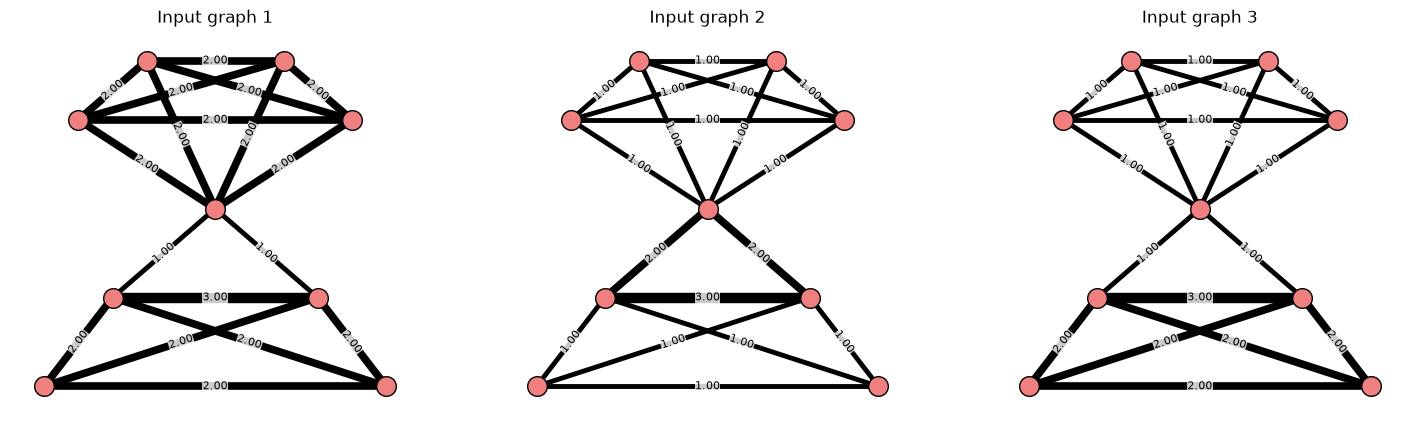

In [2]:
X, all_edges = generate_edge_weighted_graph()
print(f"X shape: {X.shape}, edges: {len(all_edges)}")
fixed_pos = {
    5: (0, 0),
    4: (-2, 1.5), 3: (-1, 2.5), 2: (1, 2.5), 1: (2, 1.5),
    6: (-1.5, -1.5), 7: (1.5, -1.5), 8: (-2.5, -3.0), 9: (2.5, -3.0),
}

_=plot_gallery_graph(X, torch.tensor(all_edges).T, title="Input graph", pos=fixed_pos)

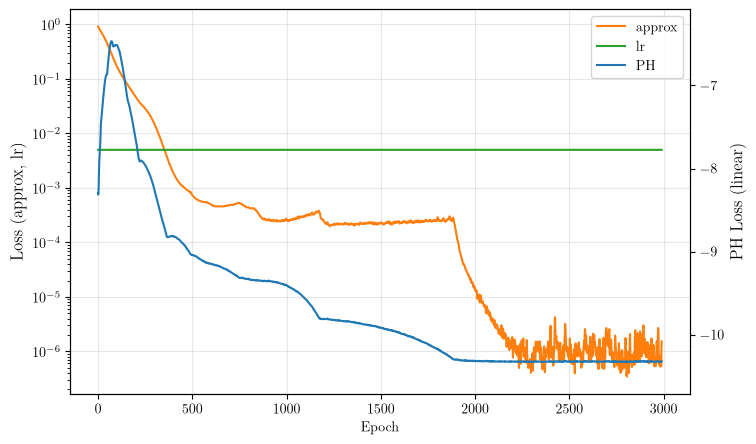

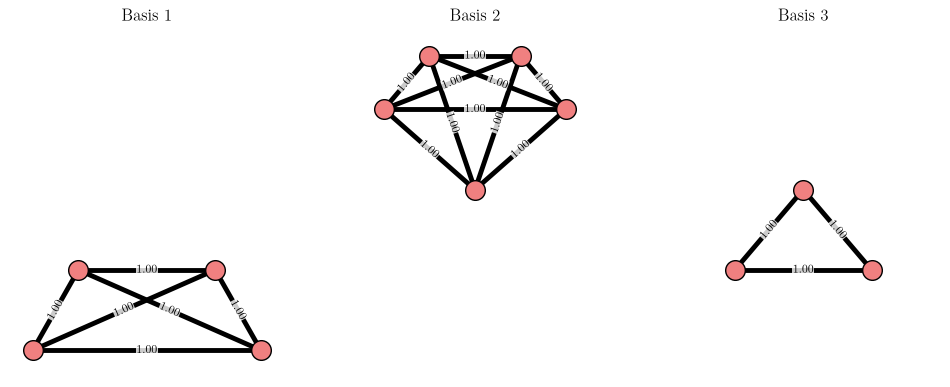

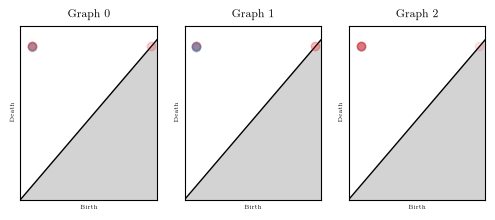

  0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
n_components = 3

# Superlevel graph filtration tracking H0 and H1
ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)

# Empty target diagrams encourage topologically simple bases
target_diagrams = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=43,
    complex=ph_complex,
    use_embedding=False,
    ph_loss_fn=clique_deviation_loss,
    ph_loss_params={"alpha": 1.0, "remove_longest": {0: False, 1: False}},
)

monitor = FitMonitor(
    show=["loss", "PH", "basis"],
    interval=10,
    factor=1.0,
    grid=(1, 3),
    superlevel=True,
    save_video=True,
    plot_size=2.0,
)

model.fit(
    X,
    n_iterations=3000,
    lr=0.005,
    lambda_top=0.01,
    PH_dims=[0, 1],
    complex_inputs={"all_edges": all_edges, "node_pos": fixed_pos},
    verbose=True,
    target_diagrams=target_diagrams,
    basis_normalization="scale",
    init_method="random",
    monitor=monitor,
)

plt.close("all")

In [4]:
monitor.save(OUTPUT_DIR / "graph.mp4", show=["basis"], fps=10)
monitor.save(OUTPUT_DIR / "graph_ph.mp4", show=["PH"], fps=10)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 452) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 226) to (608, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook/output/graph.mp4
Video saved: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook/output/graph_ph.mp4


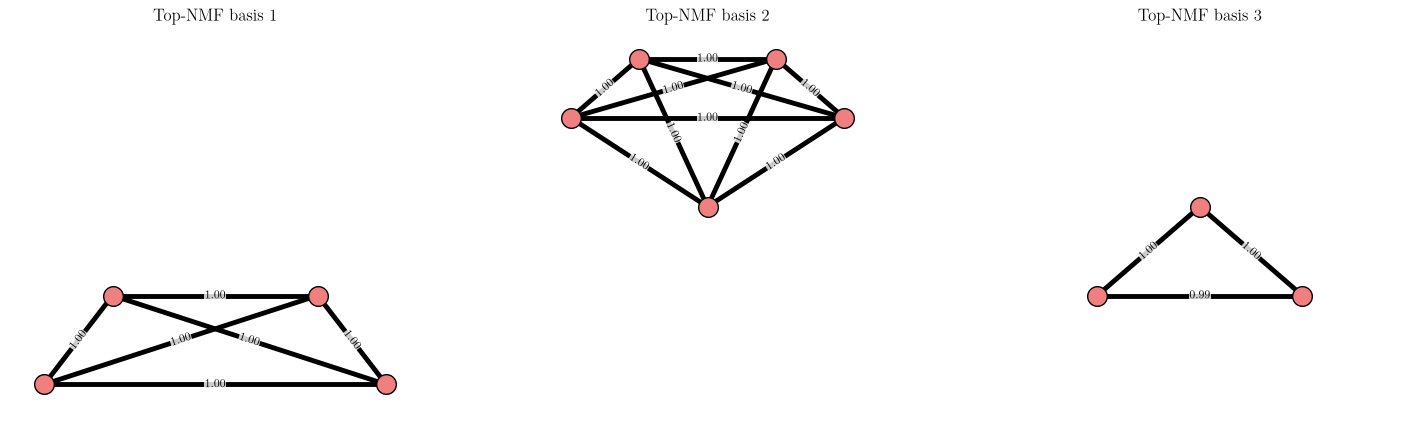

In [5]:
# Top-NMF basis vectors
_=plot_gallery_graph(
    model.V.detach().cpu().numpy(),
    torch.tensor(all_edges).T,
    title="Top-NMF basis",
    pos=fixed_pos,
)

## Compare with standard NMF

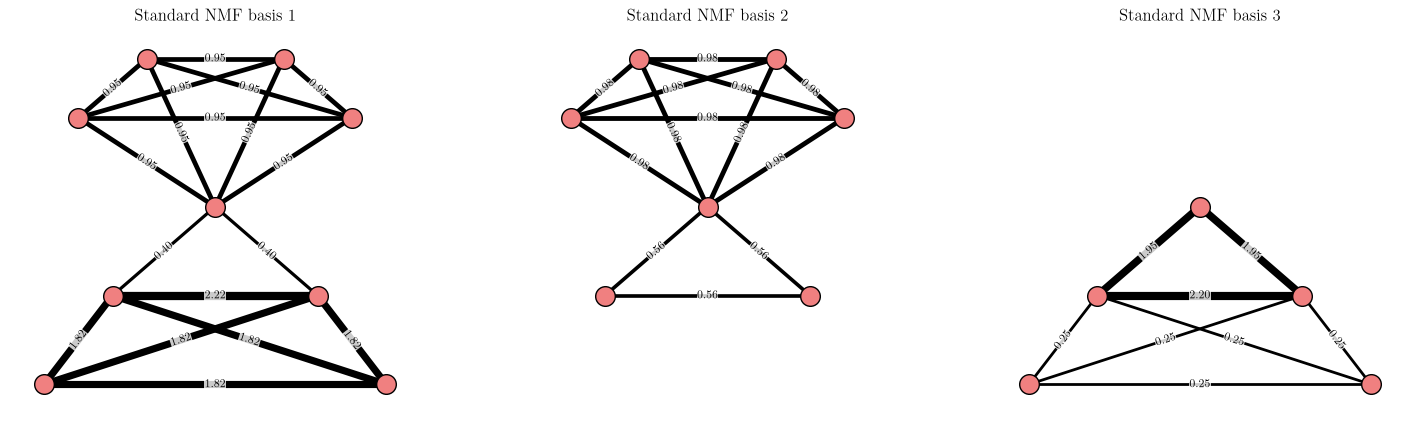

In [6]:
# Standard NMF on the same edge-weight matrix
nmf = NMF(n_components=n_components, init="random", random_state=43)
W_std = nmf.fit_transform(X)
H_std = nmf.components_

# Standard NMF basis vectors
_=plot_gallery_graph(
    H_std,
    torch.tensor(all_edges).T,
    title="Standard NMF basis",
    pos=fixed_pos,
)

## Compare with graph-regularized NMF

The graph baseline uses Nimfa `Snmnmf`, a sparse network-regularized multiple NMF implementation. The prior network is the line graph of edge features: two edge features are linked when they share an endpoint in the original graph.

In [7]:
H_net = fit_network_regularized_nmf_baseline(
    X,
    all_edges,
    rank=n_components,
    max_iter=150,
    gamma=0.03,
    lamb=0.02,
    random_state=43,
)
if H_net is not None:
    _ = plot_gallery_graph(
        H_net,
        torch.tensor(all_edges).T,
        title="Network-regularized NMF basis (Nimfa SNMNMF)",
        pos=fixed_pos,
    )


Skipping network-regularized NMF baseline; install with `pip install nimfa`.


In [ ]:
def cp_alpha_component_scores(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    alpha: float = 1.0,
) -> List[float]:
    """
    Compute the positive CP_alpha score used by ``clique_deviation_loss``.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over graph nodes.
    alpha : float, optional
        Weight for higher-dimensional persistence terms.

    Returns
    -------
    list of float
        Per-component CP_alpha scores; larger values indicate stronger clique-like topology.
    """
    ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)
    target_diagrams = [
        torch.zeros((0, 2), dtype=torch.float32, device=device),
        torch.zeros((0, 2), dtype=torch.float32, device=device),
    ]
    scores = []
    for component in components:
        component_t = torch.as_tensor(component, dtype=torch.float32, device=device)
        diagrams = ph_complex(edges, component_t)
        loss = clique_deviation_loss(
            diagrams,
            [0, 1],
            target_diagrams,
            device,
            alpha=alpha,
            remove_longest={0: False, 1: False},
        )
        scores.append(float((loss).detach().cpu().item()))
    return scores


def plot_cp_alpha_score_comparison(
    top_scores: List[float],
    standard_scores: List[float],
    title: str,
) -> Tuple[Figure, np.ndarray]:
    """
    Compare CP_alpha component scores between Top-NMF and standard NMF.

    Parameters
    ----------
    top_scores : list of float
        Top-NMF CP_alpha scores.
    standard_scores : list of float
        Standard NMF CP_alpha scores.
    title : str
        Figure title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    x = np.arange(len(top_scores))
    width = 0.36
    fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
    ax.bar(x - width / 2, top_scores, width, label="Top-NMF", color="#3b7ddd")
    ax.bar(x + width / 2, standard_scores, width, label="Standard NMF", color="#9aa5b1")
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{i + 1}" for i in x])
    ax.set_ylabel("CP_alpha score")
    ax.set_title(title)
    ax.legend(frameon=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_cp_alpha_report(
    dataset_name: str,
    top_scores: List[float],
    standard_scores: List[float],
) -> None:
    """
    Print a compact CP_alpha comparison report.

    Parameters
    ----------
    dataset_name : str
        Dataset name for display.
    top_scores : list of float
        Top-NMF CP_alpha scores.
    standard_scores : list of float
        Standard NMF CP_alpha scores.

    Returns
    -------
    None
    """
    top_mean = float(np.mean(top_scores))
    standard_mean = float(np.mean(standard_scores))
    print(
        f"{dataset_name} CP_alpha: Top-NMF mean={top_mean:.3f}, "
        f"standard NMF mean={standard_mean:.3f}, advantage={top_mean - standard_mean:.3f}"
    )


def plot_separation_comparison(
    top_stats: Dict[str, np.ndarray],
    standard_stats: Dict[str, np.ndarray],
) -> Tuple[Figure, np.ndarray]:
    """
    Compare the strongest ictal component separation for both methods.

    Parameters
    ----------
    top_stats : dict of str to np.ndarray
        Top-NMF state statistics.
    standard_stats : dict of str to np.ndarray
        Standard NMF state statistics.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    values = [float(np.max(top_stats["cohen_d"])), float(np.max(standard_stats["cohen_d"]))]
    fig, ax = plt.subplots(figsize=(4.8, 3.2), constrained_layout=True)
    ax.bar([0, 1], values, color=["#3b7ddd", "#9aa5b1"], width=0.58)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Top-NMF", "Standard NMF"])
    ax.set_ylabel("Best ictal Cohen's d")
    ax.set_title("Ictal-component separation")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_state_separation_report(
    top_stats: Dict[str, np.ndarray],
    standard_stats: Dict[str, np.ndarray],
) -> None:
    """
    Print a compact Top-NMF versus standard NMF state-separation report.

    Parameters
    ----------
    top_stats : dict of str to np.ndarray
        Top-NMF state statistics.
    standard_stats : dict of str to np.ndarray
        Standard NMF state statistics.

    Returns
    -------
    None
    """
    rows = [("Top-NMF", top_stats), ("Standard NMF", standard_stats)]
    for name, stats in rows:
        best = int(np.argmax(stats["cohen_d"]))
        print(
            f"{name}: best ictal component C{best + 1}, "
            f"delta={stats['delta'][best]:.3f}, Cohen's d={stats['cohen_d'][best]:.3f}"
        )
    advantage = float(np.max(top_stats["cohen_d"]) - np.max(standard_stats["cohen_d"]))
    if advantage >= 0:
        print(f"Top-NMF state-separation advantage over standard NMF: {advantage:.3f} Cohen's d")
    else:
        print(f"State-separation difference (Top-NMF - standard NMF): {advantage:.3f} Cohen's d")

In [9]:
top_cp_scores = cp_alpha_component_scores(model.V.detach().cpu().numpy(), all_edges)
standard_cp_scores = cp_alpha_component_scores(H_std, all_edges)
print_cp_alpha_report("Synthetic graph", top_cp_scores, standard_cp_scores)
if H_net is not None:
    network_cp_scores = cp_alpha_component_scores(H_net, all_edges)
    print(
        "Synthetic graph CP_alpha: "
        f"network-regularized NMF mean={np.mean(network_cp_scores):.3f}, "
        f"advantage over standard={np.mean(network_cp_scores) - np.mean(standard_cp_scores):.3f}"
    )


Synthetic graph CP_alpha: Top-NMF mean=10.321, standard NMF mean=13.175, advantage=-2.854


## Consolidated metric summary -- synthetic graph

In [10]:
# Consolidated metric summary -- synthetic graph (overlapping cliques)
import pandas as pd
from IPython.display import display

gt_cliques_synth = ((1, 2, 3, 4, 5), (5, 6, 7), (6, 7, 8, 9))
gt_atoms_synth = clique_indicator_atoms(gt_cliques_synth, all_edges)

V_top_graph = model.V.detach().cpu().numpy()
methods_graph = [("Top-NMF", V_top_graph), ("Standard NMF", H_std)]
if H_net is not None:
    methods_graph.append(("Network-reg. NMF", H_net))

rows_graph = []
for name, Vm in methods_graph:
    cp = cp_alpha_component_scores(Vm, all_edges)
    rows_graph.append({
        "method": name,
        "recon rel. error": recon_rel_error_nnls(X, Vm),
        "atom recovery (cos)": graph_atom_recovery(Vm, gt_atoms_synth),
        "mean CP_alpha": float(np.mean(cp)),
    })
summary_graph = pd.DataFrame(rows_graph).set_index("method")
print("Synthetic graph -- three overlapping cliques; the true atoms are the per-clique edge")
print("indicators. Higher atom recovery / CP_alpha = bases align with clean cliques. Reconstruction")
print("relative error uses the optimal non-negative coefficients (lower = better).")
display(summary_graph.round(4))


Synthetic graph -- three overlapping cliques; the true atoms are the per-clique edge
indicators. Higher atom recovery / CP_alpha = bases align with clean cliques. Reconstruction
relative error uses the optimal non-negative coefficients (lower = better).


,recon rel. error,atom recovery (cos),mean CP_alpha
method,,,
Top-NMF,0.0010,1.0000,10.3211
Standard NMF,0.0001,0.9246,13.1754


## Effect of the topological weight $\alpha$ (r = 5)

Fit Top-NMF with $r=5$ bases for $\alpha \in \{0.1, 1.0, 5.0\}$ on the same synthetic overlapping-clique graph. Small $\alpha$ favours fragmented small structures, moderate $\alpha=1.0$ recovers the intended cliques while leaving redundant bases inactive, and large $\alpha$ favours larger structures. Each panel reports its per-basis $CP_\alpha$ score (evaluated with that row's $\alpha$).

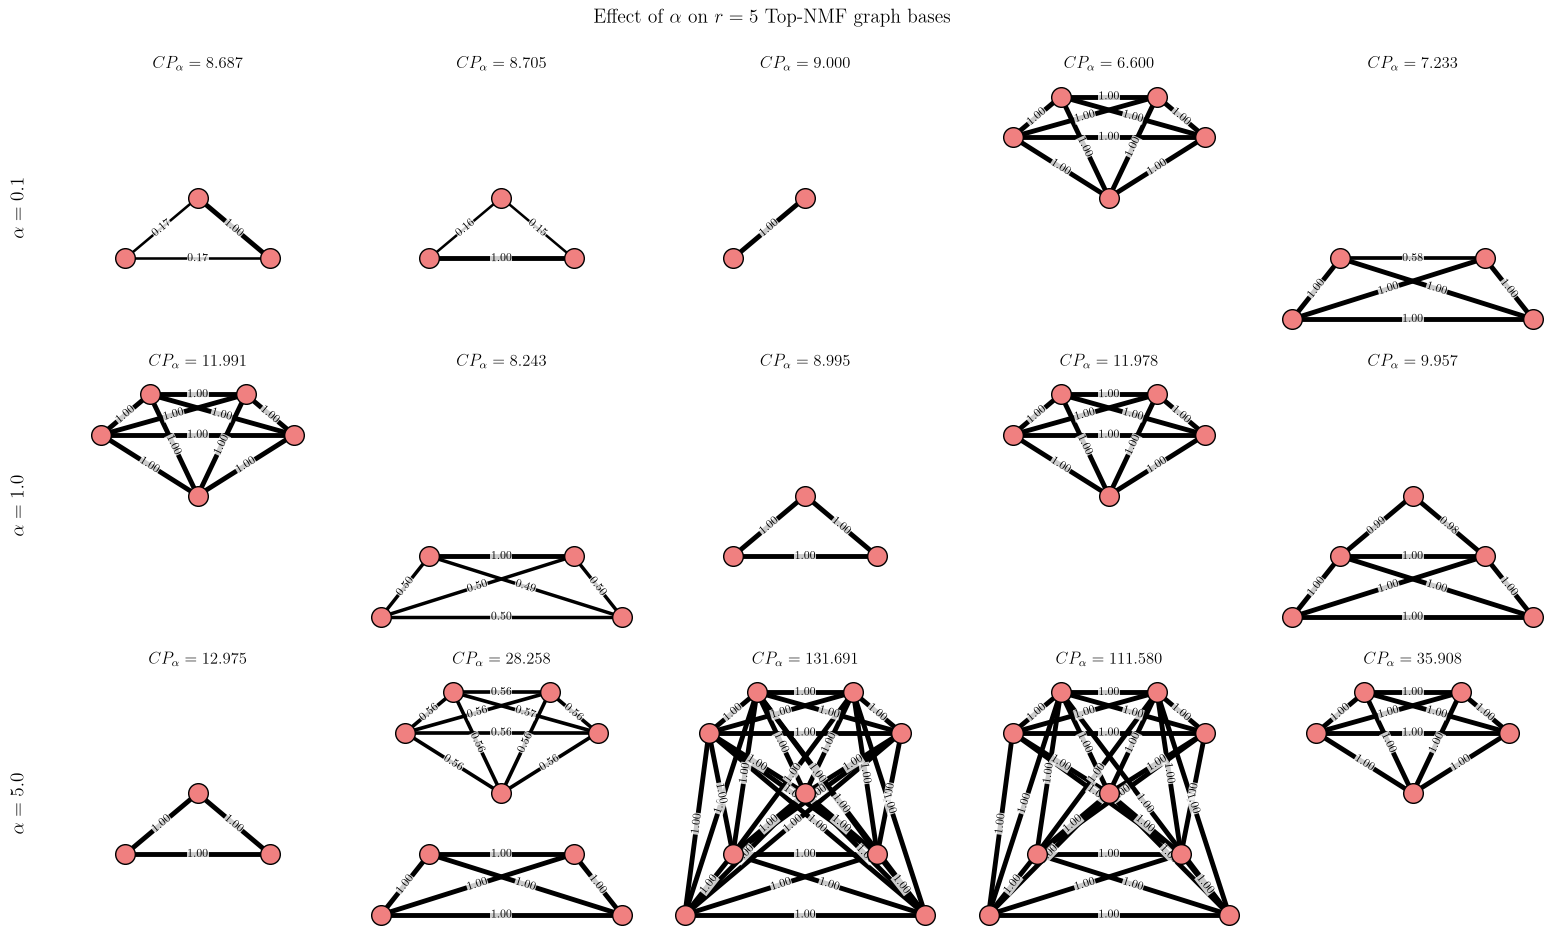

In [11]:
# Effect of alpha on r=5 Top-NMF bases (synthetic overlapping-clique graph)
alpha_values = [0.1, 1.0, 5.0]
n_components_sweep = 5

edge_index_T = torch.tensor(all_edges).T
target_diagrams_sweep = [
    torch.zeros((0, 2), dtype=torch.float32, device=device),
    torch.zeros((0, 2), dtype=torch.float32, device=device),
]

fig_alpha, axs_alpha = plt.subplots(
    len(alpha_values), n_components_sweep,
    figsize=(3.2 * n_components_sweep, 3.2 * len(alpha_values)),
)
axs_alpha = np.atleast_2d(axs_alpha)

for row, alpha in enumerate(alpha_values):
    model_alpha = TopologicalNMF(
        n_components=n_components_sweep,
        device=device,
        random_state=43,
        complex=GraphFiltrationPH(max_dim=1, superlevel=True),
        use_embedding=False,
        ph_loss_fn=clique_deviation_loss,
        ph_loss_params={"alpha": alpha, "remove_longest": {0: False, 1: False}},
    )
    model_alpha.fit(
        X,
        n_iterations=3000,
        lr=0.005,
        lambda_top=0.01,
        PH_dims=[0, 1],
        complex_inputs={"all_edges": all_edges, "node_pos": fixed_pos},
        verbose=False,
        target_diagrams=target_diagrams_sweep,
        # Rescale rather than project the basis rows; see the first fit above
        # for why the Euclidean projection (the library default) blends the
        # supports on edge-weight data.
        basis_normalization="scale",
        init_method="random",
    )

    V_alpha = model_alpha.V.detach().cpu().numpy()
    cp_scores_alpha = cp_alpha_component_scores(V_alpha, all_edges, alpha=alpha)

    plot_gallery_graph(
        V_alpha,
        edge_index_T,
        title="",
        n_col=n_components_sweep,
        n_row=1,
        axs=axs_alpha[row],
        pos=fixed_pos,
    )
    for col in range(n_components_sweep):
        axs_alpha[row, col].set_title(
            rf"$CP_\alpha = {cp_scores_alpha[col]:.3f}$", fontsize=12
        )
    axs_alpha[row, 0].text(
        -0.12, 0.5, rf"$\alpha = {alpha}$",
        transform=axs_alpha[row, 0].transAxes,
        rotation=90, va="center", ha="center", fontsize=14,
    )

fig_alpha.suptitle(r"Effect of $\alpha$ on $r=5$ Top-NMF graph bases", fontsize=14)
fig_alpha.tight_layout(rect=(0.02, 0, 1, 0.98))
fig_alpha.savefig(OUTPUT_DIR / "synthetic_graph_alpha_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

## SocioPatterns high-school contact network experiment

This section uses the SocioPatterns High School Dynamic Contact Networks datasets (**2011** and **2012** deployments) as direct clique-recovery examples for `CP_alpha`. Each deployment contains face-to-face contact records at 20-second resolution. We build sliding-window contact-duration graphs and run Top-NMF to recover within-class contact structures, comparing against standard NMF using the class-module score (within-class top-edge mass).

Both years are processed with the same pipeline so results are directly comparable. Sources: [SocioPatterns High School 2011](https://sociopatterns.org/datasets/high-school-contact-and-friendship-networks/) and [2012](https://sociopatterns.org/datasets/high-school-2012-data-set/).

In [12]:
import gzip
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from urllib.request import urlretrieve
from matplotlib.figure import Figure

SOCIOPATTERNS_CACHE_DIR = Path("data/sociopatterns")

SOCIOPATTERNS_DATASETS = {
    "2011": {
        "contact_url": "https://sociopatterns.org/assets/data/highschool_2011.csv.gz",
        "metadata_url": "https://sociopatterns.org/assets/data/highschool_2011_metadata.txt",
        "contact_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2011.csv.gz",
        "metadata_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2011_metadata.txt",
    },
    "2012": {
        "contact_url": "https://sociopatterns.org/assets/data/highschool_2012.csv.gz",
        "metadata_url": "https://sociopatterns.org/assets/data/highschool_2012_metadata.txt",
        "contact_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2012.csv.gz",
        "metadata_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2012_metadata.txt",
    },
}


def download_sociopatterns_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not output_path.exists():
        print(f"Downloading {url} -> {output_path}")
        urlretrieve(url, output_path)
    return output_path


def load_highschool_metadata(path: Path) -> Dict[int, Dict[str, str]]:
    tokens = path.read_text().split()
    metadata = {}
    for idx in range(0, len(tokens), 3):
        person_id = int(tokens[idx])
        metadata[person_id] = {"class": tokens[idx + 1], "gender": tokens[idx + 2]}
    return metadata


def load_highschool_contacts(path: Path) -> List[Tuple[int, int, int, str, str]]:
    rows = []
    with gzip.open(path, "rt") as handle:
        for line in handle:
            parts = line.split()
            if len(parts) < 5:
                continue
            rows.append((int(parts[0]), int(parts[1]), int(parts[2]), parts[3], parts[4]))
    return rows


def select_active_students_by_class(
    contacts: List[Tuple[int, int, int, str, str]],
    metadata: Dict[int, Dict[str, str]],
    per_class: int = 8,
) -> List[int]:
    activity = Counter()
    for _, left, right, _, _ in contacts:
        activity[left] += 1
        activity[right] += 1

    by_class = defaultdict(list)
    for person_id, info in metadata.items():
        class_name = info["class"]
        if class_name.lower() == "teacher":
            continue
        by_class[class_name].append(person_id)

    selected = []
    for class_name in sorted(by_class):
        ranked = sorted(by_class[class_name], key=lambda node: (-activity[node], node))
        selected.extend(ranked[:per_class])
    return selected


RUN_SOCIOPATTERNS_EXPERIMENT = True

sp_data = {}  # year -> dict with loaded data and "ready" flag

if RUN_SOCIOPATTERNS_EXPERIMENT:
    for year, cfg in SOCIOPATTERNS_DATASETS.items():
        try:
            contact_path = download_sociopatterns_file(cfg["contact_url"], cfg["contact_path"])
            metadata_path = download_sociopatterns_file(cfg["metadata_url"], cfg["metadata_path"])
            metadata = load_highschool_metadata(metadata_path)
            contacts = load_highschool_contacts(contact_path)
            selected_ids = select_active_students_by_class(contacts, metadata, per_class=8)
            node_classes = [metadata[node_id]["class"] for node_id in selected_ids]
            edges = list(combinations(range(len(selected_ids)), 2))
            sp_data[year] = {
                "contacts": contacts,
                "metadata": metadata,
                "selected_ids": selected_ids,
                "node_classes": node_classes,
                "edges": edges,
                "ready": True,
            }
            print(
                f"SocioPatterns {year}: {len(selected_ids)} nodes, "
                f"{len(edges)} edges, classes={sorted(set(node_classes))}"
            )
        except Exception as exc:
            print(f"Skipping SocioPatterns {year}: {exc}")
            sp_data[year] = {"ready": False}
else:
    print("Set RUN_SOCIOPATTERNS_EXPERIMENT = True to run the SocioPatterns experiments.")

SOCIOPATTERNS_READY = any(v["ready"] for v in sp_data.values())

SocioPatterns 2011: 24 nodes, 276 edges, classes=['PC', 'PC*', 'PSI*']
SocioPatterns 2012: 40 nodes, 780 edges, classes=['MP*1', 'MP*2', 'PC', 'PC*', 'PSI*']


In [13]:
def build_sociopatterns_contact_matrix(
    contacts: List[Tuple[int, int, int, str, str]],
    selected_ids: List[int],
    window_seconds: int = 1800,
    step_seconds: int = 900,
    contact_interval_seconds: int = 20,
    min_window_contacts: int = 4,
) -> Tuple[np.ndarray, List[Tuple[int, int]], List[Tuple[int, int]]]:
    """
    Build sliding-window contact-duration graphs.

    Parameters
    ----------
    contacts : list of tuple
        Temporal contact rows ``(t, i, j, class_i, class_j)``.
    selected_ids : list of int
        Person IDs retained as graph nodes.
    window_seconds : int, optional
        Aggregation window length.
    step_seconds : int, optional
        Sliding-window step.
    contact_interval_seconds : int, optional
        Duration represented by one active-contact row.
    min_window_contacts : int, optional
        Minimum selected-subgraph contacts required to keep a window.

    Returns
    -------
    X : np.ndarray
        Window-by-edge non-negative duration matrix.
    edges : list of tuple of int
        Complete graph edge list over selected nodes.
    bounds : list of tuple of int
        Kept window bounds in seconds.
    """
    node_lookup = {node_id: idx for idx, node_id in enumerate(selected_ids)}
    edges = list(combinations(range(len(selected_ids)), 2))
    edge_lookup = {tuple(sorted(edge)): idx for idx, edge in enumerate(edges)}
    selected_set = set(selected_ids)
    selected_contacts = [
        (time, left, right)
        for time, left, right, _, _ in contacts
        if left in selected_set and right in selected_set
    ]
    if not selected_contacts:
        raise ValueError("No contacts remain after selecting the SocioPatterns node subset.")

    times = np.asarray([time for time, _, _ in selected_contacts], dtype=int)
    start = int(times.min())
    stop = int(times.max())
    rows = []
    bounds = []
    for t0 in range(start, stop - window_seconds + step_seconds, step_seconds):
        t1 = t0 + window_seconds
        row = np.zeros(len(edges), dtype=float)
        contact_count = 0
        for time, left, right in selected_contacts:
            if t0 < time <= t1:
                u = node_lookup[left]
                v = node_lookup[right]
                row[edge_lookup[tuple(sorted((u, v)))]] += contact_interval_seconds
                contact_count += 1
        if contact_count >= min_window_contacts:
            rows.append(row)
            bounds.append((t0, t1))

    X = np.vstack(rows)
    X /= np.maximum(X.max(axis=1, keepdims=True), 1e-12)
    return X, edges, bounds


def class_block_layout(node_classes: List[str]) -> Dict[int, Tuple[float, float]]:
    """
    Place nodes in class-specific circular blocks.

    Parameters
    ----------
    node_classes : list of str
        Class label for each node.

    Returns
    -------
    dict of int to tuple of float
        Node positions for network plotting.
    """
    classes = sorted(set(node_classes))
    angles = np.linspace(0, 2 * np.pi, len(classes), endpoint=False)
    centers = {
        class_name: np.array([2.8 * np.cos(angle), 2.8 * np.sin(angle)])
        for class_name, angle in zip(classes, angles)
    }
    pos = {}
    for class_name in classes:
        nodes = [idx for idx, label in enumerate(node_classes) if label == class_name]
        local_angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
        for node_idx, angle in zip(nodes, local_angles):
            offset = np.array([0.85 * np.cos(angle), 0.85 * np.sin(angle)])
            pos[node_idx] = tuple(centers[class_name] + offset)
    return pos

In [ ]:
sp_models = {}  # year -> {"top_model": ..., "H_std": ..., "H_net": ...}

for year, data in sp_data.items():
    if not data["ready"]:
        print(f"SocioPatterns {year} fit skipped.")
        continue

    X_sp, sp_edges, sp_window_bounds = build_sociopatterns_contact_matrix(
        contacts=data["contacts"],
        selected_ids=data["selected_ids"],
        window_seconds=1800,
        step_seconds=900,
        min_window_contacts=4,
    )
    sp_pos = class_block_layout(data["node_classes"])
    print(f"SocioPatterns {year}: X shape {X_sp.shape}, kept windows: {len(sp_window_bounds)}")
    data["X"] = X_sp
    data["sp_edges"] = sp_edges
    data["sp_pos"] = sp_pos

    n_components_sp = len(sorted(set(data["node_classes"])))
    target_diagrams_sp = [
        torch.zeros((0, 2), dtype=torch.float32, device=device),
        torch.zeros((0, 2), dtype=torch.float32, device=device),
    ]

    sp_model = TopologicalNMF(
        n_components=n_components_sp,
        device=device,
        random_state=23,
        complex=GraphFiltrationPH(max_dim=1, superlevel=True),
        use_embedding=False,
        ph_loss_fn=clique_deviation_loss,
        ph_loss_params={"alpha": 1.0, "remove_longest": {0: True, 1: False}},
    )
    sp_model.fit(
        X_sp,
        n_iterations=1000,
        lr=0.005,
        lambda_top=0.0001,
        lambda_apx=1.0,
        PH_dims=[0, 1],
        complex_inputs={"all_edges": sp_edges, "node_pos": sp_pos},
        basis_normalization="scale",
        verbose=True,
        target_diagrams=target_diagrams_sp,
        init_method="nndsvda",
        scheduler_cls=None,
    )

    nmf_sp = NMF(
        n_components=n_components_sp,
        init="nndsvda",
        random_state=23,
        max_iter=5000,
        tol=1e-5,
    )
    W_sp_std = nmf_sp.fit_transform(X_sp)
    H_sp_std = nmf_sp.components_

    H_sp_net = fit_network_regularized_nmf_baseline(
        X_sp,
        sp_edges,
        rank=n_components_sp,
        max_iter=120,
        gamma=0.02,
        lamb=0.02,
        random_state=23,
    )

    sp_models[year] = {"top_model": sp_model, "H_std": H_sp_std, "H_net": H_sp_net}

if not sp_models:
    print("No SocioPatterns fits completed.")

SocioPatterns 2011: X shape (122, 276), kept windows: 122


  0%|          | 0/1000 [00:00<?, ?it/s]

Skipping network-regularized NMF baseline; install with `pip install nimfa`.
SocioPatterns 2012: X shape (278, 780), kept windows: 278


  0%|          | 0/1000 [00:00<?, ?it/s]

Skipping network-regularized NMF baseline; install with `pip install nimfa`.



--- SocioPatterns 2011 ---


Top-NMF: mean within-class mass=0.995, best=1.000, classes=['PC', 'PSI*', 'PC']
Standard NMF: mean within-class mass=0.966, best=0.970, classes=['PC', 'PSI*', 'PC']
Top-NMF class-module advantage over standard NMF: 0.029 within-class mass
SocioPatterns 2011 CP_alpha: Top-NMF mean=21.515, standard NMF mean=20.674, advantage=0.841



--- SocioPatterns 2012 ---
Top-NMF: mean within-class mass=0.999, best=1.000, classes=['MP*1', 'PSI*', 'MP*1', 'MP*1', 'PC']
Standard NMF: mean within-class mass=0.947, best=0.998, classes=['MP*1', 'PSI*', 'PC', 'MP*1', 'MP*1']
Top-NMF class-module advantage over standard NMF: 0.052 within-class mass
SocioPatterns 2012 CP_alpha: Top-NMF mean=38.128, standard NMF mean=34.504, advantage=3.623


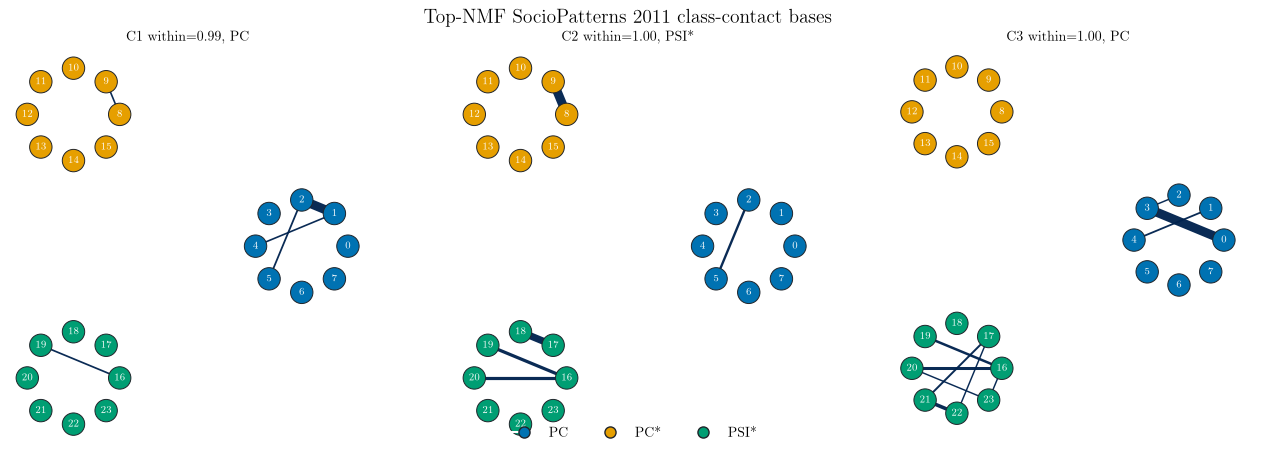

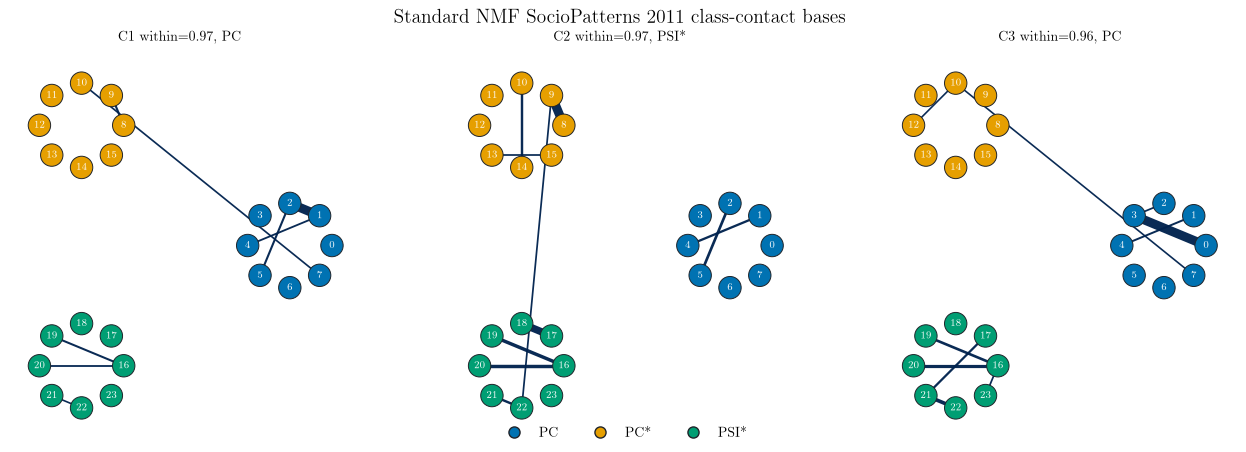

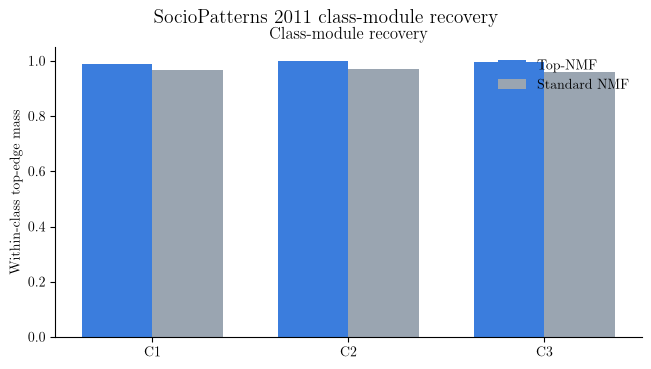

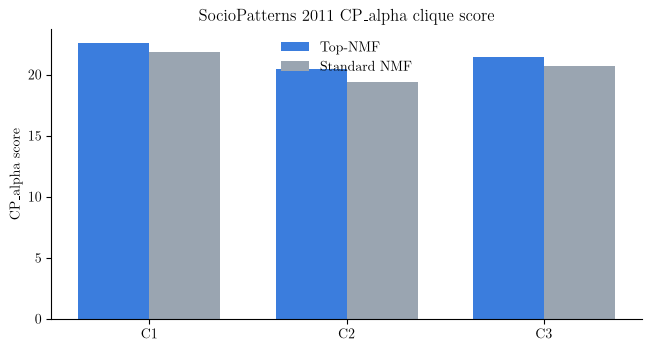

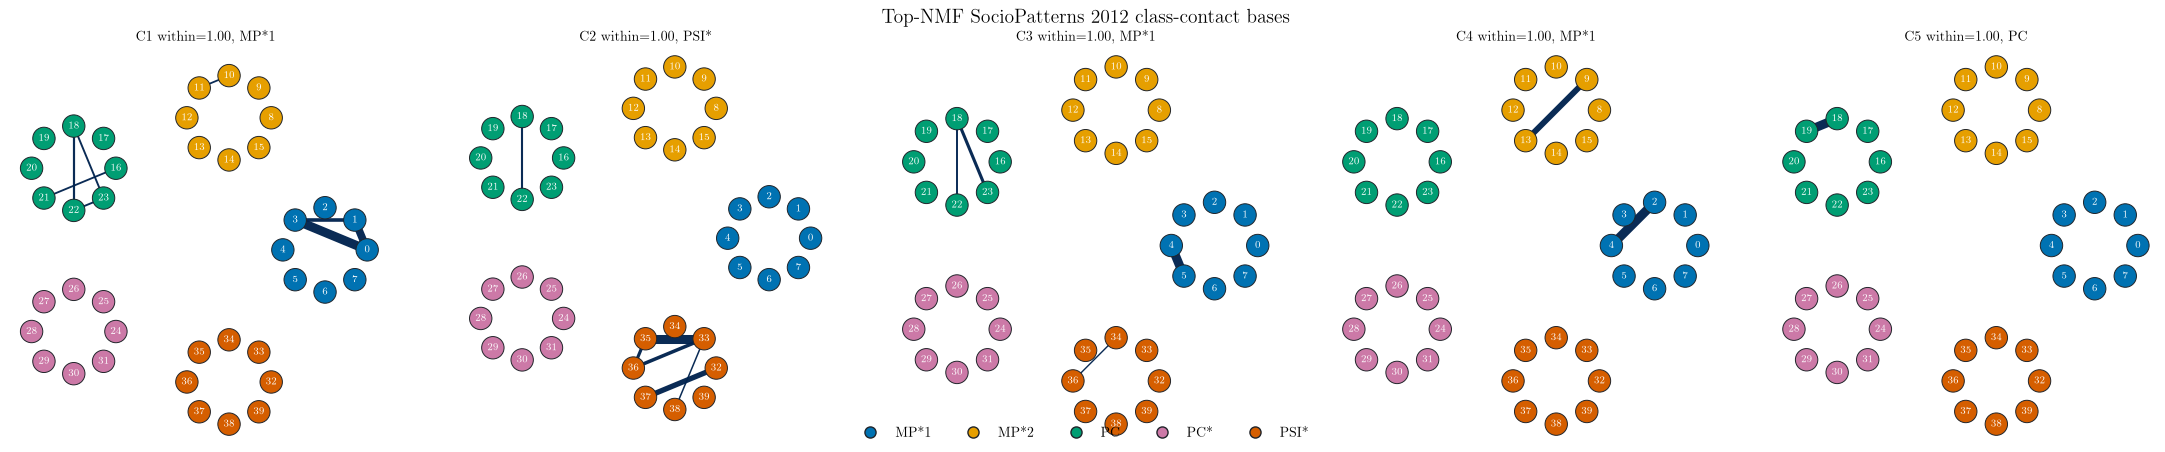

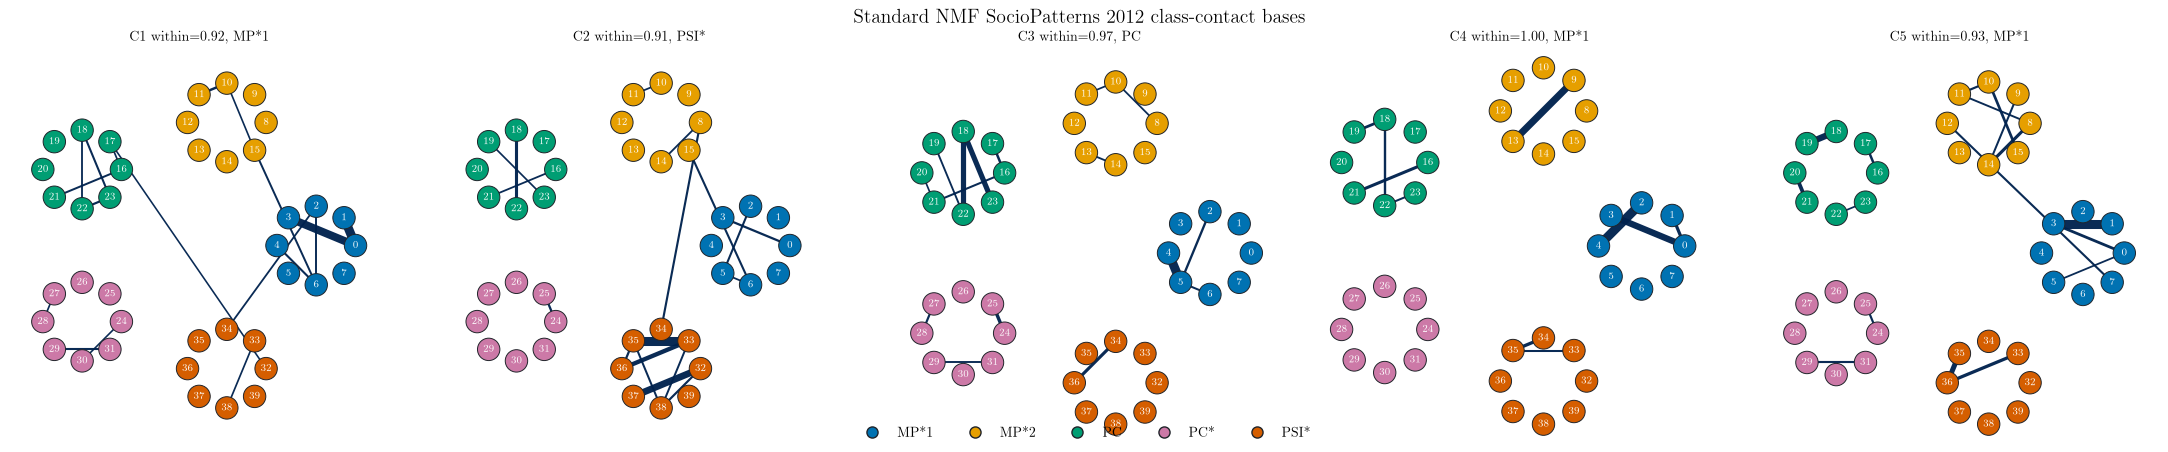

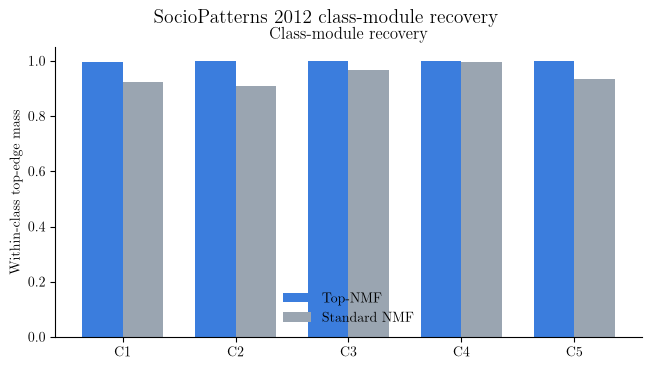

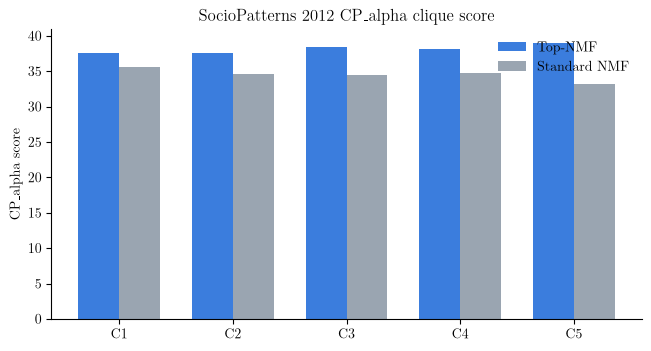

In [15]:
def component_class_module_scores(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    node_classes: List[str],
    threshold_quantile: float = 0.70,
) -> List[Dict[str, object]]:
    """
    Score how strongly each component concentrates on within-class edges.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over node indices.
    node_classes : list of str
        Class label for each node.
    threshold_quantile : float, optional
        Quantile defining top edges used for the score.

    Returns
    -------
    list of dict
        Per-component within-class and dominant-class scores.
    """
    scores = []
    for component in components:
        positive = component[component > 0]
        threshold = np.quantile(positive, threshold_quantile) if positive.size else np.inf
        total_weight = 0.0
        within_weight = 0.0
        class_weight = defaultdict(float)
        for edge_idx, (u, v) in enumerate(edges):
            weight = float(component[edge_idx])
            if weight < threshold:
                continue
            total_weight += weight
            if node_classes[u] == node_classes[v]:
                within_weight += weight
                class_weight[node_classes[u]] += weight
        dominant_class = max(class_weight, key=class_weight.get) if class_weight else "none"
        dominant_weight = float(class_weight[dominant_class]) if class_weight else 0.0
        scores.append({
            "within_ratio": within_weight / max(total_weight, 1e-12),
            "dominant_class": dominant_class,
            "dominant_ratio": dominant_weight / max(total_weight, 1e-12),
        })
    return scores


def plot_sociopatterns_components(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    node_classes: List[str],
    pos: Dict[int, Tuple[float, float]],
    title: str,
    scores: Optional[List[Dict[str, object]]] = None,
    threshold_quantile: float = 0.85,
) -> Tuple[Figure, np.ndarray]:
    """
    Plot SocioPatterns components with nodes colored by class.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over node indices.
    node_classes : list of str
        Class label for each node.
    pos : dict of int to tuple of float
        Node positions.
    title : str
        Figure title.
    scores : list of dict, optional
        Per-component module scores for title annotations.
    threshold_quantile : float, optional
        Quantile defining displayed edges.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    classes = sorted(set(node_classes))
    palette = dict(zip(classes, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]))
    node_colors = [palette[node_classes[idx]] for idx in range(len(node_classes))]
    max_weight = max(float(np.max(components)), 1e-12)
    n_components_local = components.shape[0]
    fig, axes = plt.subplots(
        1,
        n_components_local,
        figsize=(4.4 * n_components_local, 4.2),
        squeeze=False,
        constrained_layout=True,
    )

    for comp_idx, ax in enumerate(axes.ravel()):
        component = components[comp_idx]
        positive = component[component > 0]
        threshold = np.quantile(positive, threshold_quantile) if positive.size else np.inf
        graph = nx.Graph()
        graph.add_nodes_from(range(len(node_classes)))
        selected_edges = []
        selected_weights = []
        for edge_idx, (u, v) in enumerate(edges):
            weight = float(component[edge_idx])
            if weight >= threshold:
                graph.add_edge(u, v, weight=weight)
                selected_edges.append((u, v))
                selected_weights.append(weight)

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_color=node_colors,
            edgecolors="#20242a",
            node_size=260,
            linewidths=0.7,
            ax=ax,
        )
        if selected_edges:
            nx.draw_networkx_edges(
                graph,
                pos,
                edgelist=selected_edges,
                edge_color=selected_weights,
                edge_cmap=plt.cm.cividis,
                edge_vmin=max_weight, #threshold,
                edge_vmax=max_weight,
                width=[1.0 + 5.5 * weight / max_weight for weight in selected_weights],
                alpha=0.96,
                ax=ax,
            )
        nx.draw_networkx_labels(
            graph,
            pos,
            labels={node: str(node) for node in graph.nodes},
            font_size=7,
            font_color="white",
            ax=ax,
        )
        subtitle = f"C{comp_idx + 1}"
        if scores is not None:
            subtitle += f"  within={scores[comp_idx]['within_ratio']:.2f}, {scores[comp_idx]['dominant_class']}"
        ax.set_title(subtitle, fontsize=10)
        ax.set_aspect("equal")
        ax.axis("off")

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[class_name],
                   markeredgecolor="#20242a", markersize=8, label=class_name)
        for class_name in classes
    ]
    fig.legend(handles=handles, loc="lower center", ncol=len(classes), frameon=False)
    fig.suptitle(title, y=1.04, fontsize=14)
    return fig, axes


def plot_class_module_score_comparison(
    top_scores: List[Dict[str, object]],
    standard_scores: List[Dict[str, object]],
) -> Tuple[Figure, np.ndarray]:
    """
    Compare within-class top-edge mass between methods.

    Parameters
    ----------
    top_scores : list of dict
        Top-NMF component class-module scores.
    standard_scores : list of dict
        Standard NMF component class-module scores.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    top_values = [float(score["within_ratio"]) for score in top_scores]
    standard_values = [float(score["within_ratio"]) for score in standard_scores]
    x = np.arange(len(top_values))
    width = 0.36
    fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
    ax.bar(x - width / 2, top_values, width, label="Top-NMF", color="#3b7ddd")
    ax.bar(x + width / 2, standard_values, width, label="Standard NMF", color="#9aa5b1")
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{i + 1}" for i in x])
    ax.set_ylabel("Within-class top-edge mass")
    ax.set_title("Class-module recovery")
    ax.legend(frameon=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_class_module_report(
    top_scores: List[Dict[str, object]],
    standard_scores: List[Dict[str, object]],
) -> None:
    """
    Print a compact class-module recovery report.

    Parameters
    ----------
    top_scores : list of dict
        Top-NMF component class-module scores.
    standard_scores : list of dict
        Standard NMF component class-module scores.

    Returns
    -------
    None
    """
    for name, scores in [("Top-NMF", top_scores), ("Standard NMF", standard_scores)]:
        mean_within = float(np.mean([score["within_ratio"] for score in scores]))
        best_within = float(np.max([score["within_ratio"] for score in scores]))
        classes = [str(score["dominant_class"]) for score in scores]
        print(f"{name}: mean within-class mass={mean_within:.3f}, best={best_within:.3f}, classes={classes}")
    advantage = float(
        np.mean([score["within_ratio"] for score in top_scores])
        - np.mean([score["within_ratio"] for score in standard_scores])
    )
    print(f"Top-NMF class-module advantage over standard NMF: {advantage:.3f} within-class mass")


def to_numpy_matrix(value: object) -> np.ndarray:
    """Convert a tensor-like matrix to a NumPy array."""
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def reconstruction_error(
    X: np.ndarray,
    W: object,
    H: object,
) -> Dict[str, float]:
    """Compute absolute and relative Frobenius reconstruction error."""
    W_np = to_numpy_matrix(W)
    H_np = to_numpy_matrix(H)
    residual = X - W_np @ H_np
    absolute_error = float(np.linalg.norm(residual, ord="fro"))
    baseline = float(np.linalg.norm(X, ord="fro"))
    relative_error = absolute_error / max(baseline, 1e-12)
    return {"absolute": absolute_error, "relative": relative_error}


def print_reconstruction_error_report(
    dataset_name: str,
    top_error: Dict[str, float],
    standard_error: Dict[str, float],
) -> None:
    """Print a compact reconstruction error report."""
    print(
        f"{dataset_name} reconstruction error: "
        f"Top-NMF abs={top_error['absolute']:.3f}, rel={top_error['relative']:.3f}; "
        f"standard NMF abs={standard_error['absolute']:.3f}, rel={standard_error['relative']:.3f}"
    )


for year, data in sp_data.items():
    if not data["ready"] or year not in sp_models:
        print(f"SocioPatterns {year} visualization skipped.")
        continue

    sp_model = sp_models[year]["top_model"]
    H_sp_std = sp_models[year]["H_std"]
    H_sp_net = sp_models[year].get("H_net")
    sp_edges = data["sp_edges"]
    sp_pos = data["sp_pos"]
    node_classes = data["node_classes"]
    X_sp = data["X"]

    V_sp = sp_model.V.detach().cpu().numpy()
    H_sp_std_norm = H_sp_std / np.maximum(H_sp_std.max(axis=1, keepdims=True), 1e-12)
    top_scores_sp = component_class_module_scores(V_sp, sp_edges, node_classes)
    standard_scores_sp = component_class_module_scores(H_sp_std_norm, sp_edges, node_classes)
    H_sp_net_norm = None if H_sp_net is None else H_sp_net / np.maximum(H_sp_net.max(axis=1, keepdims=True), 1e-12)
    network_scores_sp = None if H_sp_net_norm is None else component_class_module_scores(H_sp_net_norm, sp_edges, node_classes)
    top_cp_scores_sp = cp_alpha_component_scores(V_sp, sp_edges)
    standard_cp_scores_sp = cp_alpha_component_scores(H_sp_std_norm, sp_edges)
    network_cp_scores_sp = None if H_sp_net_norm is None else cp_alpha_component_scores(H_sp_net_norm, sp_edges)

    top_W_sp = getattr(sp_model, "W", getattr(sp_model, "W_", None))
    top_H_sp = getattr(sp_model, "V", getattr(sp_model, "H", None))
    if top_W_sp is None or top_H_sp is None:
        raise AttributeError("TopologicalNMF does not expose factor matrices needed for reconstruction error.")

    #top_reconstruction = reconstruction_error(X_sp, top_W_sp, top_H_sp)
    #standard_reconstruction = reconstruction_error(X_sp, W_sp_std, H_sp_std)

    fig_sp_top, _ = plot_sociopatterns_components(
        V_sp,
        sp_edges,
        node_classes,
        sp_pos,
        title=f"Top-NMF SocioPatterns {year} class-contact bases",
        scores=top_scores_sp,
    )
    fig_sp_std, _ = plot_sociopatterns_components(
        H_sp_std_norm,
        sp_edges,
        node_classes,
        sp_pos,
        title=f"Standard NMF SocioPatterns {year} class-contact bases",
        scores=standard_scores_sp,
    )
    fig_sp_net = None
    if H_sp_net_norm is not None:
        fig_sp_net, _ = plot_sociopatterns_components(
            H_sp_net_norm,
            sp_edges,
            node_classes,
            sp_pos,
            title=f"Network-regularized NMF SocioPatterns {year} class-contact bases",
            scores=network_scores_sp,
        )
    fig_sp_score, _ = plot_class_module_score_comparison(top_scores_sp, standard_scores_sp)
    fig_sp_score.suptitle(f"SocioPatterns {year} class-module recovery", y=1.04, fontsize=14)
    fig_sp_cp, _ = plot_cp_alpha_score_comparison(
        top_cp_scores_sp,
        standard_cp_scores_sp,
        title=f"SocioPatterns {year} CP_alpha clique score",
    )

    print(f"\n--- SocioPatterns {year} ---")
    print_class_module_report(top_scores_sp, standard_scores_sp)
    if network_scores_sp is not None:
        mean_network = float(np.mean([score["within_ratio"] for score in network_scores_sp]))
        print(f"Network-regularized NMF: mean within-class mass={mean_network:.3f}")
    #print_reconstruction_error_report(f"SocioPatterns {year}", top_reconstruction, standard_reconstruction)
    print_cp_alpha_report(f"SocioPatterns {year}", top_cp_scores_sp, standard_cp_scores_sp)
    if network_cp_scores_sp is not None:
        print(
            f"SocioPatterns {year} CP_alpha: network-regularized NMF "
            f"mean={np.mean(network_cp_scores_sp):.3f}, "
            f"advantage over standard={np.mean(network_cp_scores_sp) - np.mean(standard_cp_scores_sp):.3f}"
        )

    fig_sp_top.savefig(OUTPUT_DIR / f"sociopatterns_{year}_topnmf_class_contact_basis.png", dpi=300, bbox_inches="tight")
    fig_sp_std.savefig(OUTPUT_DIR / f"sociopatterns_{year}_standard_nmf_class_contact_basis.png", dpi=300, bbox_inches="tight")
    if fig_sp_net is not None:
        fig_sp_net.savefig(OUTPUT_DIR / f"sociopatterns_{year}_network_regularized_nmf_class_contact_basis.png", dpi=300, bbox_inches="tight")
    fig_sp_score.savefig(OUTPUT_DIR / f"sociopatterns_{year}_class_module_score_comparison.png", dpi=300, bbox_inches="tight")
    fig_sp_cp.savefig(OUTPUT_DIR / f"sociopatterns_{year}_cp_alpha_score_comparison.png", dpi=300, bbox_inches="tight")

## Consolidated metric summary -- SocioPatterns

In [16]:
# Consolidated metric summary -- SocioPatterns (per year, all methods)
import pandas as pd
from IPython.display import display


def _mean_within(scores):
    return float(np.mean([s["within_ratio"] for s in scores]))


rows_sp = []
for year, data in sp_data.items():
    if not data.get("ready") or year not in sp_models:
        continue
    sp_edges = data["sp_edges"]
    node_classes = data["node_classes"]
    X_sp = data["X"]
    sp_model = sp_models[year]["top_model"]
    H_sp_std = sp_models[year]["H_std"]
    H_sp_net = sp_models[year].get("H_net")

    V_sp = sp_model.V.detach().cpu().numpy()
    H_sp_std_norm = H_sp_std / np.maximum(H_sp_std.max(axis=1, keepdims=True), 1e-12)
    H_sp_net_norm = (None if H_sp_net is None
                     else H_sp_net / np.maximum(H_sp_net.max(axis=1, keepdims=True), 1e-12))

    methods_sp = [("Top-NMF", V_sp), ("Standard NMF", H_sp_std_norm)]
    if H_sp_net_norm is not None:
        methods_sp.append(("Network-reg. NMF", H_sp_net_norm))

    for name, Vm in methods_sp:
        within = _mean_within(component_class_module_scores(Vm, sp_edges, node_classes))
        cp = float(np.mean(cp_alpha_component_scores(Vm, sp_edges)))
        rows_sp.append({
            "year": year,
            "method": name,
            "recon rel. error": recon_rel_error_nnls(X_sp, Vm),
            "within-class mass": within,
            "mean CP_alpha": cp,
        })

if rows_sp:
    summary_sp = pd.DataFrame(rows_sp).set_index(["year", "method"])
    print("SocioPatterns -- class-labelled contact networks (no atom ground truth). The target is")
    print("recovery of within-class contact modules: higher within-class mass / CP_alpha = cleaner")
    print("class modules. Reconstruction relative error uses optimal NNLS coefficients.")
    display(summary_sp.round(4))
else:
    print("No SocioPatterns fits available for the summary.")


SocioPatterns -- class-labelled contact networks (no atom ground truth). The target is
recovery of within-class contact modules: higher within-class mass / CP_alpha = cleaner
class modules. Reconstruction relative error uses optimal NNLS coefficients.


recon rel. error  within-class mass  mean CP_alpha
year method                                                          
2011 Top-NMF                 0.6532             0.9952        21.5150
     Standard NMF            0.6488             0.9660        20.6742
2012 Top-NMF                 0.7631             0.9993        38.1275
     Standard NMF            0.7313             0.9470        34.5043